# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías

import pandas as pd


import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos

df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv') 
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
-`visitas_mes`
-`compras_mes`
-`gasto_publicidad_dirigida`
-`satisfaccion`
-`ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados, utilizando los tipos `float64` e `int64`. **No se identifican valores nulos**, por lo que no es necesario realizar una limpieza relacionada con datos faltantes.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype(int)

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000



**Diagnóstico inicial de variables numéricas**

- **edad** — La edad promedio es de 38.26 años, con valores entre 18 y 75 años.
  
- **nivel_ingreso** — El ingreso anual estimado promedio es de 30,019.70, con un rango entre 8,000 y 74,790.84.
  
- **visitas_mes** — Los clientes realizan en promedio 10.03 visitas al mes, con un mínimo de 1 y un máximo de 25 visitas.
  
- **compras_mes** — El promedio es de 1.21 compras al mes, mientras que el máximo registrado es de 8 compras.

- **gasto_publicidad_dirigida** — El gasto promedio es de 20.15, con valores que van desde 0 hasta 75.51.

- **satisfaccion** — La satisfacción promedio es de 3.60 sobre 5, con valores entre 1 y 5.

- **miembro_premium** — El promedio de 0.1393 indica que aproximadamente 13.9% de los clientes tienen membresía premium.

- **abandono** — El promedio de 0.1507 indica que aproximadamente 15.1% de los clientes han abandonado la plataforma.

- **ingreso_anual** — El ingreso anual promedio generado por cliente es de 36.59, con valores entre 0 y 244.69.


#### Explorar variables binarias

In [7]:
#Verificar que cada columna tenga únicamente dos valores posibles
print("Valores únicos de miembro_premium:", df['miembro_premium'].unique()) 
print("Valores únicos de abandono:", df['abandono'].unique())

Valores únicos de miembro_premium: [0 1]
Valores únicos de abandono: [0 1]


**Diagnóstico inicial de variables binarias**

- `miembro_premium` — La variable contiene únicamente los valores 0 y 1, por lo que está correctamente codificada. El valor promedio de 0.1393 indica que aproximadamente 13.9% de los clientes cuentan con membresía premium.
  
- `abandono` — La variable contiene únicamente los valores 0 y 1, por lo que está correctamente codificada. El valor promedio de 0.1507 indica que aproximadamente 15.1% de los clientes han abandonado la plataforma.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
print("Valores únicos en tipo_dispositivo:", df['tipo_dispositivo'].nunique()) 
print("Valores únicos en region:", df['region'].nunique())


Valores únicos en tipo_dispositivo: 3
Valores únicos en region: 4


In [9]:
# Explorar variables categóricas y cómo se distribuyen
print("Distribución de tipo_dispositivo:") 
print(df['tipo_dispositivo'].value_counts()) 
print("\nDistribución de region:") 
print(df['region'].value_counts())

Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


**Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — Presenta 3 categorías: móvil, escritorio y tablet. La categoría más frecuente es móvil, con 9,818 clientes, seguida de escritorio con 3,720 y tablet con 1,462. Esto muestra una mayor concentración de clientes que utilizan dispositivos móviles.

- `region` — Presenta 4 categorías: norte, oeste, sur y este. La región con mayor número de clientes es norte, con 4,395, mientras que la región este presenta la menor cantidad, con 3,069 clientes. La distribución regional es relativamente equilibrada en comparación con la distribución por tipo de dispositivo.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

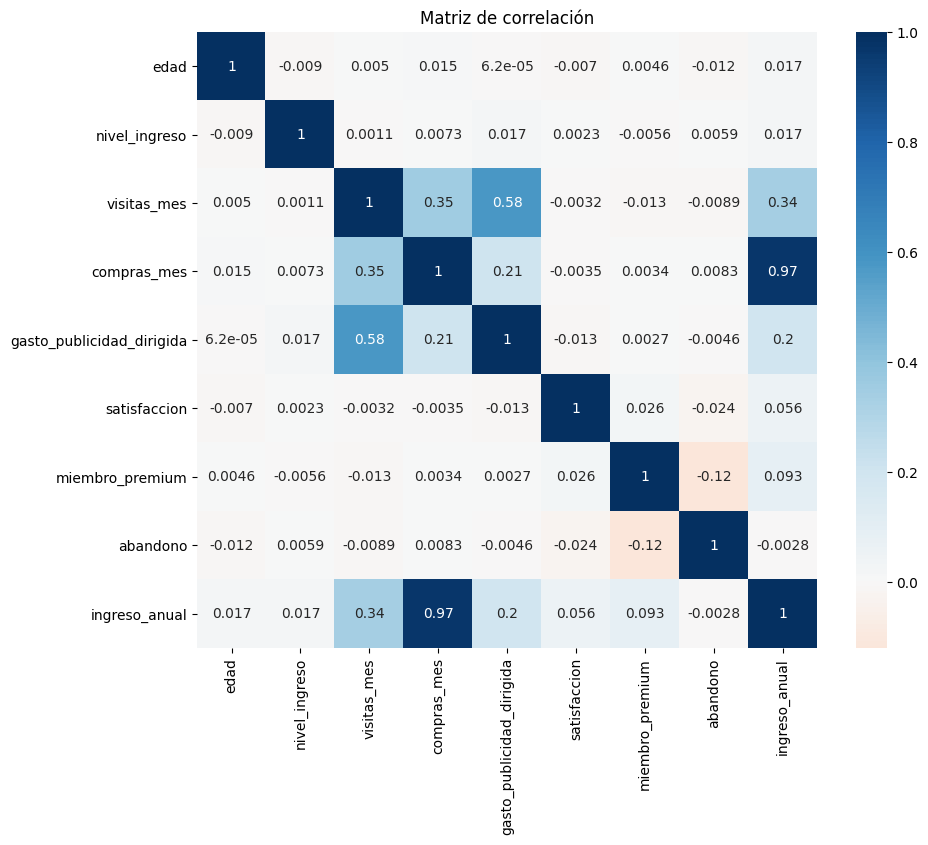

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
df_numerico = df.select_dtypes(include=['number']) 
corr = df_numerico.corr() 

plt.figure(figsize=(10, 8)) 
sns.heatmap(corr, annot=True, cmap='RdBu', center=0) 
plt.title('Matriz de correlación') 
plt.show()

**Observaciones generales (Heatmap)**
- Se observa que la mayoría de las variables presentan correlaciones débiles, con valores cercanos a cero. Esto indica que, en general, no existe una relación lineal fuerte entre las variables analizadas.

**Observaciones respecto a `ingreso_anual`**
- Presenta correlaciones débiles con las demás variables, por lo que no se observa una relación lineal significativa entre el ingreso anual y las variables analizadas.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

Se decide incluir un scatterplot debido a que el análisis de correlación identificó una relación positiva moderada entre visitas_ultimos_30d y gasto_publicitario_dirigido. El gráfico permitirá observar visualmente si existe una tendencia entre ambas variables.

Se observa una tendencia positiva moderada: conforme aumenta el gasto publicitario dirigido, también tiende a aumentar el número de visitas en los últimos 30 días. Sin embargo, los puntos presentan cierta dispersión, por lo que la relación no es completamente fuerte.

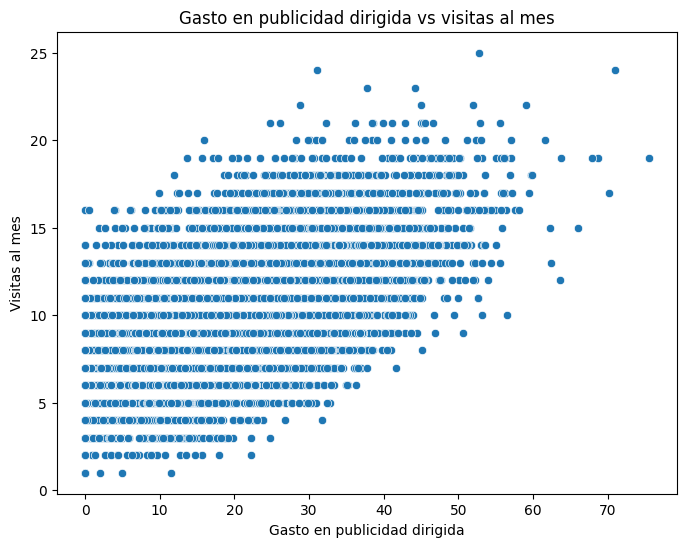

In [11]:
# Scatterplot: gasto en publicidad dirigida vs visitas al mes

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='gasto_publicidad_dirigida',
    y='visitas_mes'
)

plt.title('Gasto en publicidad dirigida vs visitas al mes')
plt.xlabel('Gasto en publicidad dirigida')
plt.ylabel('Visitas al mes')
plt.show()


In [12]:
# Mostrar los nombres de todas las columnas
print(df.columns.tolist())

['id_cliente', 'edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'miembro_premium', 'abandono', 'tipo_dispositivo', 'region', 'ingreso_anual']


### Scatterplot para pares clave

In [13]:
# Visualizar pares de variables con relaciones moderadas o fuertes
df_numerico = df.select_dtypes(include='number')

corr = df_numerico.corr()

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        valor = corr.iloc[i, j]
        
        if abs(valor) >= 0.5:
            print(corr.columns[i], "vs", corr.columns[j], ":", round(valor, 2))

visitas_mes vs gasto_publicidad_dirigida : 0.58
compras_mes vs ingreso_anual : 0.97


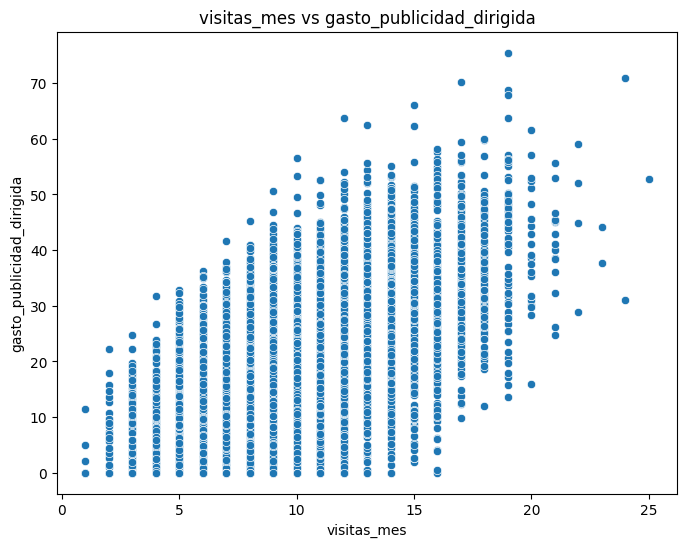

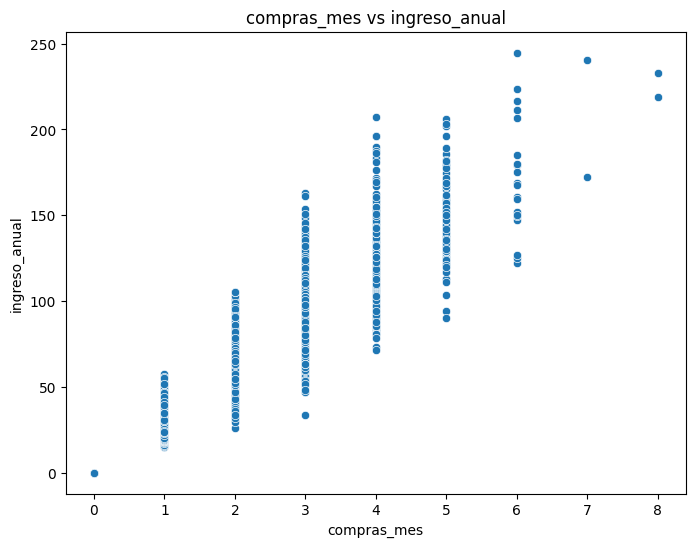

In [14]:
# Scatterplots de los pares con relaciones moderadas o fuertes

pares = [
    ('visitas_mes', 'gasto_publicidad_dirigida'),
    ('compras_mes', 'ingreso_anual')
]

for x, y in pares:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f'{x} vs {y}')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

**Observaciones iniciales (Scatterplot)**

**visitas_mes vs gasto_publicidad_dirigida**
- Dirección: positiva; a medida que aumenta el gasto en publicidad dirigida, tienden a aumentar las visitas al mes.
- Dispersión: media, consistente con una correlación positiva moderada de 0.58.
- Outliers: no se identifican de manera concluyente sin una revisión visual detallada de los puntos.
- Colinealidad: no se considera preocupante, ya que la correlación es moderada.

**compras_mes vs ingreso_anual**
- Dirección: positiva y muy fuerte; los valores de compras al mes aumentan de manera muy marcada junto con el ingreso anual.
- Dispersión: baja, consistente con una correlación de 0.97.
- Outliers: no se identifican de manera concluyente sin una revisión visual detallada de los puntos.
- Colinealidad: existe una relación lineal muy fuerte entre ambas variables, por lo que debe considerarse posible colinealidad si las dos variables se utilizan posteriormente en un mismo modelo.
 

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [15]:
# Calcular correlación entre variables relevantes
pares = [
    ('visitas_mes', 'gasto_publicidad_dirigida'),
    ('compras_mes', 'ingreso_anual')
]

for var1, var2 in pares:
    pearson = df[var1].corr(df[var2], method='pearson')
    spearman = df[var1].corr(df[var2], method='spearman')
    
    print(var1, "vs", var2)
    print("Pearson:", round(pearson, 4))
    print("Spearman:", round(spearman, 4))
    print()

visitas_mes vs gasto_publicidad_dirigida
Pearson: 0.5789
Spearman: 0.5593

compras_mes vs ingreso_anual
Pearson: 0.9671
Spearman: 0.9675



In [16]:
# Calcular correlación entre variables relevantes
df_numerico = df.select_dtypes(include='number')

corr = df_numerico.corr()

corr


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
edad,1.000000,-0.009003,0.004998,0.014971,0.000062,-0.006963,0.004605,-0.011500,0.017496
nivel_ingreso,-0.009003,1.000000,0.001060,0.007309,0.016834,0.002301,-0.005598,0.005870,0.017446
visitas_mes,0.004998,0.001060,1.000000,0.353844,0.578947,-0.003179,-0.012657,-0.008943,0.337147
compras_mes,0.014971,0.007309,0.353844,1.000000,0.207528,-0.003542,0.003431,0.008291,0.967149
gasto_publicidad_dirigida,0.000062,0.016834,0.578947,0.207528,1.000000,-0.013175,0.002721,-0.004586,0.197483
satisfaccion,-0.006963,0.002301,-0.003179,-0.003542,-0.013175,1.000000,0.025734,-0.023833,0.056171
miembro_premium,0.004605,-0.005598,-0.012657,0.003431,0.002721,0.025734,1.000000,-0.120488,0.093099
abandono,-0.011500,0.005870,-0.008943,0.008291,-0.004586,-0.023833,-0.120488,1.000000,-0.002824
ingreso_anual,0.017496,0.017446,0.337147,0.967149,0.197483,0.056171,0.093099,-0.002824,1.000000


**Observaciones de correlación**

***`visitas_mes` vs `gasto_publicidad_dirigida`***

**Correlación positiva moderada:** *Pearson* = 0.5789 y *Spearman* = 0.5593.

La similitud entre ambos coeficientes confirma una relación positiva consistente. No se observa una posible colinealidad preocupante entre estas variables debido a que la correlación es moderada.

***`compras_mes` vs `ingreso_anual`***

**Correlación positiva muy fuerte:** *Pearson* = 0.9671 y *Spearman* = 0.9675.

La relación es prácticamente lineal y existe una posible colinealidad alta entre ambas variables, por lo que se debe tener precaución al utilizarlas simultáneamente en un modelo.

### Punto-biserial

In [17]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

correlacion, p_valor = pointbiserialr(
    df['miembro_premium'],
    df['satisfaccion']
)

print("Correlación punto-biserial:", round(correlacion, 4))
print("P-valor:", round(p_valor, 4))

Correlación punto-biserial: 0.0257
P-valor: 0.0016


In [18]:
correlacion_abandono, p_valor_abandono = pointbiserialr(
    df['abandono'],
    df['satisfaccion']
)

print("abandono vs satisfaccion")
print("Correlación punto-biserial:", round(correlacion_abandono, 4))
print("P-valor:", round(p_valor_abandono, 4))

abandono vs satisfaccion
Correlación punto-biserial: -0.0238
P-valor: 0.0035


**Observaciones Punto-biserial**

**`miembro_premium` vs `satisfaccion`**
Relación positiva muy débil (0.0257). 

Aunque el resultado es estadísticamente significativo, la magnitud de la relación es prácticamente nula.

**`abandono` vs `satisfaccion`**
Relación negativa muy débil (-0.0238). 

Aunque el resultado es estadísticamente significativo, la magnitud de la relación es prácticamente nula.

### V de Cramér

In [19]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    phi2 = chi2 / n
    r, k = tabla.shape
    
    return np.sqrt(phi2 / min(k - 1, r - 1))

In [20]:
# Aplicar V de Cramér en variables relevantes
pares = [
    ('region', 'tipo_dispositivo'),
    ('region', 'miembro_premium'),
    ('tipo_dispositivo', 'miembro_premium')
]

for var1, var2 in pares:
    resultado = cramers_v(df[var1], df[var2])
    print(var1, "vs", var2, ":", round(resultado, 4))


region vs tipo_dispositivo : 0.0124
region vs miembro_premium : 0.0126
tipo_dispositivo vs miembro_premium : 0.0197


**Observaciones V de Cramér**

**`region` vs `tipo_dispositivo`**
Relación prácticamente nula (V de Cramér = 0.0124), por lo que no se observa una asociación relevante entre la región y el tipo de dispositivo.

**`region` vs `miembro_premium`**
Relación prácticamente nula (V de Cramér = 0.0126), lo que indica poca o ninguna asociación entre la región y la pertenencia al programa premium.

**`tipo_dispositivo` vs `miembro_premium`**
Relación prácticamente nula (V de Cramér = 0.0197), por lo que no se observa una asociación relevante entre el tipo de dispositivo y la pertenencia al programa premium.

## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 — Publicidad y visitas

**Evidencia visual:** el scatterplot muestra una tendencia ascendente.

**Evidencia numérica:** Pearson = 0.5789 y Spearman = 0.5593.

**Interpretación**  
Existe una relación positiva moderada entre el gasto en publicidad dirigida y las visitas mensuales.

**No podemos afirmar**  
Que aumentar el gasto publicitario cause un aumento de visitas.

**Implicación de negocio**  
Puede ser útil analizar con mayor detalle la efectividad de las campañas y qué segmentos generan mayor respuesta.

### Hallazgo 2 — Compras e ingreso anual

**Evidencia visual:**  el scatterplot muestra una relación positiva muy marcada.

**Evidencia numérica:** Pearson = 0.9671 y Spearman = 0.9675. 

**Interpretación**  
Existe una relación positiva muy fuerte entre las compras mensuales y el ingreso anual.

**No podemos afirmar**  
Que un aumento en las compras sea necesariamente la causa de un mayor ingreso anual, o viceversa.

**Implicación de negocio**  
Estas variables contienen información muy relacionada y debe revisarse su posible redundancia antes de utilizarlas simultáneamente en modelos predictivos.


### Hallazgo 3 — Membresía premium y satisfacción

**Evidencia numérica:** correlación punto-biserial = 0.0257, p = 0.0016.

**Interpretación:** existe una relación positiva estadísticamente significativa, pero de magnitud prácticamente nula.

**No podemos afirmar:** que la membresía premium mejore la satisfacción.

**Implicación de negocio:** no parece suficiente considerar la membresía premium como un factor relevante para explicar la satisfacción; conviene analizar otros factores.

### Hallazgo 4 — Abandono y satisfacción

**Evidencia numérica:** correlación punto-biserial = -0.0238, p = 0.0035.
    
**Interpretación:** existe una relación negativa estadísticamente significativa, pero prácticamente nula en magnitud.
    
**No podemos afirmar:** que una menor satisfacción provoque el abandono.
    
**Implicación de negocio:** la satisfacción por sí sola no parece ser un indicador suficientemente fuerte del abandono, por lo que sería conveniente incorporar otras variables al análisis.

## Sección 6 - Limitaciones y próximos pasos

### Limitaciones
- Correlación ≠ causalidad.
  
- Algunas correlaciones, aunque sean estadísticamente significativas, presentan una magnitud muy baja y tienen poca relevancia práctica.

- La fuerte correlación entre compras_mes e ingreso_anual puede generar problemas de colinealidad si ambas variables se utilizan simultáneamente en un modelo.
  
### Próximos pasos

**Probar segmentación adicional**

- Analizar los resultados por region.
- Comparar los patrones según tipo_dispositivo y miembro_premium.

**Analizar factores asociados al abandono**

- Incorporar otras variables del comportamiento del cliente para identificar factores que puedan estar relacionados con el abandono.

**Evaluar modelos predictivos**

- Construir un modelo que permita identificar qué variables tienen mayor capacidad para explicar o predecir el comportamiento de los clientes.
